=== Training Q-Learning Agent ===
Episode 0, Avg Reward (last 100): -10.14, Epsilon: 0.995
Episode 200, Avg Reward (last 100): 5.47, Epsilon: 0.365
Episode 400, Avg Reward (last 100): 8.91, Epsilon: 0.134
Episode 600, Avg Reward (last 100): 9.92, Epsilon: 0.049
Episode 800, Avg Reward (last 100): 9.73, Epsilon: 0.018
Episode 1000, Avg Reward (last 100): 9.93, Epsilon: 0.010
Episode 1200, Avg Reward (last 100): 9.93, Epsilon: 0.010
Episode 1400, Avg Reward (last 100): 9.93, Epsilon: 0.010
Episode 1600, Avg Reward (last 100): 9.83, Epsilon: 0.010
Episode 1800, Avg Reward (last 100): 9.93, Epsilon: 0.010

=== Test Run (Optimal Policy) ===
Path Length: 8 steps
Test Reward: 9.93
Path: [0, 1, 2, 3, 8, 13, 14, 19, 24]


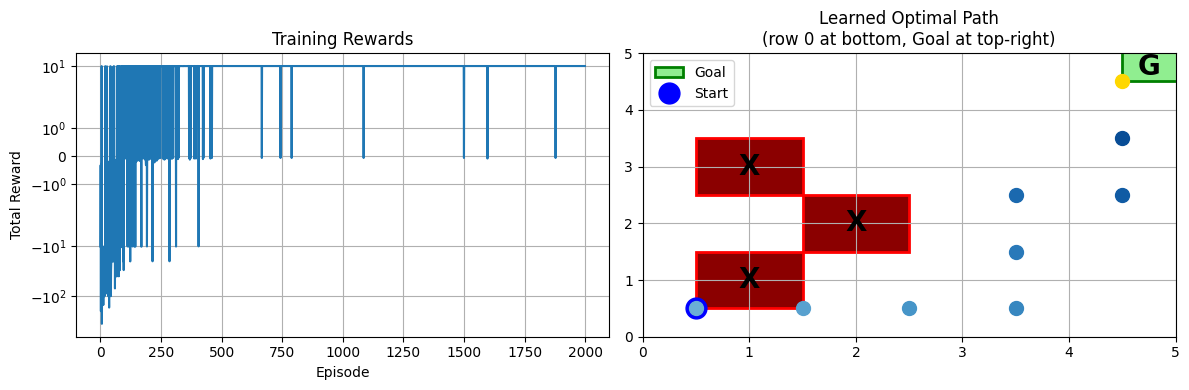

In [10]:
# ========================================
# CDS524 Assignment 1:Grid World with Q-Learning
# Author:chengbinhuang-3161001
# ========================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import pickle
import random

# ========================================
# 1. Grid World Environment
# ========================================
class GridWorld:
    def __init__(self, size=5):
        self.size = size
        self.num_states = size * size
        self.num_actions = 4
        self.actions = ['↑', '↓', '←', '→']
        self.start_state = 0
        self.goal_state = size*size - 1
        self.obstacles = [6, 12, 16]  # (1,1), (2,2), (3,1)
        self.reset()

    def reset(self):
        self.state = self.start_state
        return self.state

    def state_to_pos(self, state):
        return divmod(state, self.size)  # row, col

    def pos_to_state(self, row, col):
        return row * self.size + col

    def step(self, action):
        row, col = self.state_to_pos(self.state)

        if action == 0: row = max(0, row - 1)      # Up
        elif action == 1: row = min(self.size-1, row + 1)  # Down
        elif action == 2: col = max(0, col - 1)    # Left
        elif action == 3: col = min(self.size-1, col + 1)  # Right

        new_state = self.pos_to_state(row, col)

        if new_state in self.obstacles:
            reward = -10
            new_state = self.state  # stay
            done = False
        elif new_state == self.goal_state:
            reward = 10
            done = True
        else:
            reward = -0.01
            done = False

        self.state = new_state
        return new_state, reward, done

    def render(self, ax, agent_pos=None, path=None, title='Grid World'):
        ax.clear()
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_xticks(range(self.size + 1))
        ax.set_yticks(range(self.size + 1))
        ax.grid(True)

        # Goal
        goal_patch = patches.Rectangle((self.size-0.5, self.size-0.5), 1, 1,
                                       linewidth=2, edgecolor='green', facecolor='lightgreen', label='Goal')
        ax.add_patch(goal_patch)
        ax.text(self.size-0.25, self.size-0.25, 'G', ha='center', va='center', fontsize=20, fontweight='bold')

        # Obstacles
        for obs in self.obstacles:
            r, c = self.state_to_pos(obs)

            obs_patch = patches.Rectangle((c-0.5, r-0.5), 1, 1,
                                          linewidth=2, edgecolor='red', facecolor='darkred')
            ax.add_patch(obs_patch)
            ax.text(c, r, 'X', ha='center', va='center', fontsize=20, fontweight='bold')

        # Start
        sr, sc = self.state_to_pos(self.start_state)
        ax.plot(sc + 0.5, sr + 0.5, 'bo', markersize=15, label='Start')

        # Agent
        if agent_pos is not None:
            r, c = self.state_to_pos(agent_pos)
            ax.plot(c + 0.5, r + 0.5, 'ro', markersize=15, label='Agent')

        # Path
        if path is not None:
            for i, s in enumerate(path):
                r, c = self.state_to_pos(s)
                color = plt.cm.Blues(0.5 + 0.5 * i / len(path)) if i < len(path)-1 else 'gold'
                ax.plot(c + 0.5, r + 0.5, 'o', color=color, markersize=10)

        ax.set_title(title + "\n(row 0 at bottom, Goal at top-right)")
        ax.legend()


# ========================================
# 2. Q-Learning Agent
# ========================================
class QLearner:
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.env = env
        self.q_table = np.zeros((env.num_states, env.num_actions))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

    def choose_action(self, state, train=True):
        if train and np.random.random() < self.epsilon:
            return np.random.randint(self.env.num_actions)
        return np.argmax(self.q_table[state])

    def train(self, episodes=2000):
        rewards = []
        for ep in range(episodes):
            state = self.env.reset()
            total_reward = 0
            done = False
            steps = 0
            while not done and steps < 1000:
                action = self.choose_action(state, train=True)
                next_state, reward, done = self.env.step(action)
                best_next = np.max(self.q_table[next_state])
                self.q_table[state, action] += self.alpha * (
                    reward + self.gamma * best_next - self.q_table[state, action]
                )
                state = next_state
                total_reward += reward
                steps += 1
            rewards.append(total_reward)
            self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)
            if ep % 200 == 0:
                print(f'Episode {ep}, Avg Reward (last 100): {np.mean(rewards[-100:]):.2f}, Epsilon: {self.epsilon:.3f}')
        return rewards

    def test_policy(self, max_steps=100):
        state = self.env.reset()
        path = [state]
        total_reward = 0
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = np.argmax(self.q_table[state])
            next_state, reward, done = self.env.step(action)
            path.append(next_state)
            total_reward += reward
            state = next_state
            steps += 1
        return path, total_reward

    def save_qtable(self, filename='q_table.pkl'):
        with open(filename, 'wb') as f:
            pickle.dump(self.q_table, f)

# ========================================
# 3. Run & Visualize
# ========================================
def run_training_and_demo():
    env = GridWorld(size=5)
    ql = QLearner(env)

    print("=== Training Q-Learning Agent ===")
    rewards = ql.train(episodes=2000)
    ql.save_qtable()

    # training curve
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(rewards)
    plt.title('Training Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.yscale('symlog')
    plt.grid(True)

    # best route
    path, test_reward = ql.test_policy()
    print(f"\n=== Test Run (Optimal Policy) ===")
    print(f"Path Length: {len(path)-1} steps")
    print(f"Test Reward: {test_reward:.2f}")
    print("Path:", path)

    # static route graph
    plt.subplot(1, 2, 2)
    env.render(plt.gca(), path=path, title='Learned Optimal Path')
    plt.tight_layout()
    plt.show()

    # animation
    fig, ax = plt.subplots(figsize=(6, 6))

    start_frame = max(0, len(path) - 5)

    def animate(frame_idx):
        ax.clear()
        actual_frame = start_frame + frame_idx
        env.render(ax, agent_pos=path[actual_frame], path=path[:actual_frame+1],
                   title=f'Last Steps → Goal (Step {actual_frame}/{len(path)-1})')

    ani = FuncAnimation(fig, animate, frames=len(path) - start_frame,
                        interval=800, repeat=True)
    plt.close(fig)
    return ani, rewards, path, test_reward

In [11]:
from IPython.display import HTML
HTML(ani.to_jshtml())